# Experiment 01 — Zero-Shot Baseline

**Model:** `google/mt5-small`  
**Goal:** Establish a floor ROUGE score with no fine-tuning.  
**Columns:** `ID` | `input` | `output` | `subset` (e.g. `Aka_Gha`, `Swa_Ken`)

## Install dependencies

In [ ]:
!pip install -q transformers datasets peft bitsandbytes accelerate rouge-score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.9 MB/s eta 0:00:00


## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/health_qa/'
SAVE_DIR = '/content/drive/MyDrive/health_qa/outputs/'

import os
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


## Imports and seed

In [ ]:
import random, re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.notebook import tqdm
from rouge_score import rouge_scorer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## Load data

In [ ]:
train_df = pd.read_csv(DATA_DIR + 'Train.csv')
val_df   = pd.read_csv(DATA_DIR + 'Val.csv')
test_df  = pd.read_csv(DATA_DIR + 'Test.csv')

print(f'Train : {train_df.shape}')
print(f'Val   : {val_df.shape}')
print(f'Test  : {test_df.shape}')
print()
print('Columns:', train_df.columns.tolist())
train_df.head(3)

Train : (29815, 4)
Val   : (6686, 4)
Test  : (2618, 3)

Columns: ['ID', 'input', 'output', 'subset']


,ID,input,output,subset
0,ID_TR_Aka_Gha_A3B1799D,Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a...,Mmabun betumi aboa atipɛnfo a ebia nsa anaa nn...,Aka_Gha
1,ID_TR_Aka_Gha_1C80317F,Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu...,"Wɔ Ghana mu no, amanmmra no gye binary gender ...",Aka_Gha
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔ...,Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔ...,Aka_Gha


## Parse language and country from `subset`

`subset` format is `Lang_Country`, e.g. `Aka_Gha` → language=`Akan`, country=`Ghana`.

In [ ]:
SUBSET_MAP = {
    'Aka_Gha': ('Akan',    'Ghana'),
    'Amh_Eth': ('Amharic', 'Ethiopia'),
    'Lug_Uga': ('Luganda', 'Uganda'),
    'Swa_Ken': ('Swahili', 'Kenya'),
    'Swa_Tan': ('Swahili', 'Tanzania'),
    'Swa_Uga': ('Swahili', 'Uganda'),
    'Eng_Gha': ('English', 'Ghana'),
    'Eng_Uga': ('English', 'Uganda'),
    'Eng_Ken': ('English', 'Kenya'),
}

for df in [train_df, val_df, test_df]:
    df['language'] = df['subset'].map(lambda s: SUBSET_MAP.get(s, (s, ''))[0])
    df['country']  = df['subset'].map(lambda s: SUBSET_MAP.get(s, ('', s))[1])

print(train_df[['subset', 'language', 'country']].drop_duplicates().sort_values('subset').to_string(index=False))

 subset language  country
Aka_Gha     Akan    Ghana
Amh_Eth  Amharic Ethiopia
Eng_Eth  Eng_Eth  Eng_Eth
Eng_Gha  English    Ghana
Eng_Ken  English    Kenya
Eng_Uga  English   Uganda
Lug_Uga  Luganda   Uganda
Swa_Ken  Swahili    Kenya


## Exploratory data analysis

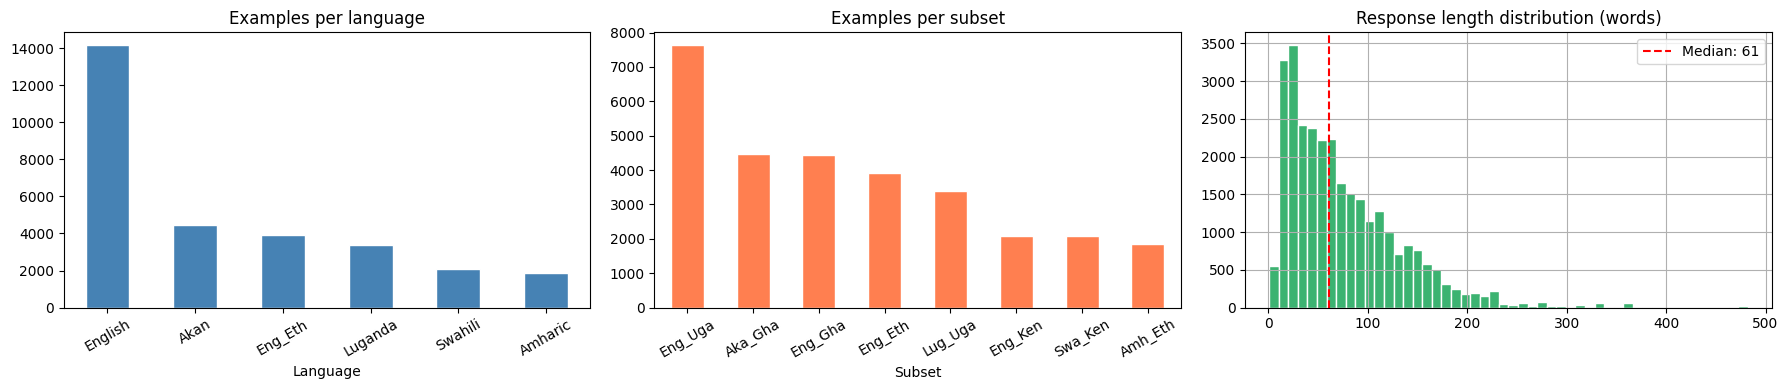

Median output length (words): 61.0
95th percentile: 184.0


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

train_df['language'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Examples per language')
axes[0].set_xlabel('Language')
axes[0].tick_params(axis='x', rotation=30)

train_df['subset'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Examples per subset')
axes[1].set_xlabel('Subset')
axes[1].tick_params(axis='x', rotation=30)

train_df['output_len'] = train_df['output'].str.split().str.len()
train_df['output_len'].hist(bins=50, ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Response length distribution (words)')
axes[2].axvline(train_df['output_len'].median(), color='red', linestyle='--',
                label=f"Median: {train_df['output_len'].median():.0f}")
axes[2].legend()

plt.tight_layout()
plt.savefig(SAVE_DIR + 'eda_overview.png', dpi=150)
plt.show()

print('Median output length (words):', train_df['output_len'].median())
print('95th percentile:', train_df['output_len'].quantile(0.95))

## Language × country cross-tab

In [ ]:
pd.crosstab(train_df['language'], train_df['country'])

country,Eng_Eth,Ethiopia,Ghana,Kenya,Uganda
language,,,,,
Akan,0,0,4455,0,0
Amharic,0,1845,0,0,0
Eng_Eth,3915,0,0,0,0
English,0,0,4443,2080,7624
Luganda,0,0,0,0,3383
Swahili,0,0,0,2070,0


## Clean text and build prompts

In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'[\r\n\t]+', ' ', text)
    return re.sub(r' {2,}', ' ', text).strip()

def build_prompt(question, language, country=''):
    header = f'Language: {language}'
    if country:
        header += f' | Country: {country}'
    return f'{header}\nQuestion: {question}\nAnswer:'

for df in [train_df, val_df, test_df]:
    df['input_clean'] = df['input'].apply(clean_text)
    df['prompt_text'] = df.apply(
        lambda r: build_prompt(r['input_clean'], r['language'], r['country']), axis=1
    )

for df in [train_df, val_df]:
    df['output_clean'] = df['output'].apply(clean_text)

print(train_df['prompt_text'].iloc[0])
print()
print(train_df['output_clean'].iloc[0])

Language: Akan | Country: Ghana
Question: Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔanya mmoa firi nnwumakuo a ɛfata hɔ, ne sɛnea wɔbɛsiw afɔbu suban ne nsɛm a nkurɔfoɔ de gu oyarefoɔ no so no kwan.
Answer:

Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagye wɔn nkate atom a wɔremmu atɛn anaasɛ wɔmfa asodi nto wɔn so. Wɔn a wɔbɛhyɛ wɔn nkuran ma wɔakɔhwehwɛ ayaresa na wɔanya mmoa nnwuma te sɛ afotu, telefon a wɔde frɛ nkurɔfo wɔ ɔhaw mu, anaa ahyehyɛde ahorow a wɔkamfo nkurɔfo. Boa a wɔbɛboa wɔn ma wɔafa akwan horow a wɔbɛfa so abɔ amanneɛ, a nea ɛka ho ne sɛ wɔbɛkɔ mmarahyɛ baguafo nkyɛn anaasɛ wɔbɛhwehwɛ mmara kwan so mmoa sɛ wɔpɛ sɛ wɔde mmara kwan so asɛm bɛkɔ atia nea ɔyɛɛ wɔ bɔne no a. Su ne nneyɛe a wɔde to nea wɔayɛ no bɔne so a wɔbɛkasa atia denam si a wobesi so dua sɛ asɛyɛde no da nea ɔyɛɛ bɔne no so,

## Load model (zero-shot — no training)

In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

MODEL_NAME = 'google/mt5-small'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model      = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()
print('Loaded.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Loaded.


## Batch generation helper

In [ ]:
def generate_batch(prompts, batch_size=8, max_new_tokens=200):
    model.eval()
    predictions = []
    for i in tqdm(range(0, len(prompts), batch_size)):
        batch  = prompts[i : i + batch_size]
        inputs = tokenizer(batch, return_tensors='pt', padding=True,
                            truncation=True, max_length=512).to(DEVICE)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                  num_beams=4, no_repeat_ngram_size=3, early_stopping=True)
        predictions.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
    return predictions

## ROUGE evaluation helper

In [ ]:
_scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=False)

def evaluate_rouge(predictions, references):
    r1s, rls = [], []
    for pred, ref in zip(predictions, references):
        s = _scorer.score(ref, pred)
        r1s.append(s['rouge1'].fmeasure)
        rls.append(s['rougeL'].fmeasure)
    return {
        'rouge1': round(sum(r1s) / len(r1s), 4),
        'rougeL': round(sum(rls) / len(rls), 4),
    }

## Validate on 200-example sample

In [ ]:
val_sample = val_df.sample(200, random_state=SEED).reset_index(drop=True)
val_preds  = generate_batch(val_sample['prompt_text'].tolist())
scores     = evaluate_rouge(val_preds, val_sample['output_clean'].tolist())

print(f"ROUGE-1 F1 : {scores['rouge1']}")
print(f"ROUGE-L F1 : {scores['rougeL']}")
print(f"Est. LB    : {0.37*scores['rouge1'] + 0.37*scores['rougeL']:.4f}")

  0%|          | 0/25 [00:00<?, ?it/s]

ROUGE-1 F1 : 0.0001
ROUGE-L F1 : 0.0001
Est. LB    : 0.0001


## Generate test predictions and build submission CSV

In [ ]:
test_preds = generate_batch(test_df['prompt_text'].tolist())

submission = pd.DataFrame({
    'ID':         test_df['ID'].values,
    'TargetRLF1': test_preds,
    'TargetR1F1': test_preds,
    'TargetLLM':  test_preds,
})

out_path = SAVE_DIR + 'exp01_zero_shot_baseline.csv'
submission.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
submission.head(3)

  0%|          | 0/328 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/health_qa/outputs/exp01_zero_shot_baseline.csv


,ID,TargetRLF1,TargetR1F1,TargetLLM
0,ID_TS_Aka_Gha_A3B1799D,<extra_id_0> Ghana,<extra_id_0> Ghana,<extra_id_0> Ghana
1,ID_TS_Aka_Gha_1C80317F,<extra_id_0>?eловна,<extra_id_0>?eловна,<extra_id_0>?eловна
2,ID_TS_Aka_Gha_06671AD1,<extra_id_0>.,<extra_id_0>.,<extra_id_0>.


## Results

| Metric | Score |
|--------|-------|
| ROUGE-1 F1 | *0.0001* |
| ROUGE-L F1 | *0.0001* |
| Zindi LB score |*0.00172*|

**Insight:** Zero-shot mT5-small is our floor. Fine-tuning on the training data is the clear next step.